# 国九条 + 小市值策略回测

克隆自聚宽文章 [国九小市值策略](https://www.joinquant.com/post/47791) / [国九条后中小板微盘小改](https://www.joinquant.com/post/47946)，迁移至本地两阶段回测框架。

## 策略逻辑

1. **主板 + 次新过滤**：剔除 ChiNext (SZSE.3xxxxx)、科创板 (SHSE.688xxx)、北交所 (BSE.xxx)，上市满 375 天
2. **市值筛选**：总市值 10 ~ 100 亿元，选市值最小 `STOCK_NUM` 只
3. **国九条盈利代理**：`pe_ttm > 0` + `pb > 1`（本地无细分 ROE/ROA/净利润数据，用 PE/PB 做代理，经前期确认 `keep_proxy`）
4. **价格护栏**：`close <= 50`，当日未涨停（否则无法买入）
5. **调仓频率**：每 `REFRESH_RATE = 5` 个交易日调仓（≈ 周度），**完全换仓**：卖出全部旧持仓，按新选股等权买入
6. **空仓月份**：1 月、4 月清仓（原策略 pass_months 规则，简化为持现金不买货币 ETF）

## 与聚宽原策略差异

| 项 | 原策略 | 本地回测 |
|---|---|---|
| 盈利过滤 | 净利润 > 0, ROE > 0, 营收 > 1亿 | `pe_ttm > 0` 且 `pb > 1` 代理 |
| 调仓日期 | 每周二 10:00 | 每 5 个交易日，开盘价成交 |
| 调仓方式 | 保留交集 + 昨日涨停保留 | 简化为完全换仓（对齐 `小市值策略.ipynb` 模板） |
| 空仓月份 ETF | 持有 511880 | 简化为持现金 |
| 止损 | 单股 9% 止损 + 大盘趋势 | 本地版省略（靠周度调仓自然换仓） |
| 审计意见过滤 | 可选 | 省略（本地无数据） |

## 回测框架

- **主线（Option C）**：组合式调仓，直接生成 `orders_df` 交给 `Backtester` 做真实资金回测，使用 `backtester.report()` 出图
- **附录（Option B）**：将调仓日筛出的股票当作单日信号，用 `cal_trade_info + trade_weekly_portfolio` 做等权理论回测作为对照

In [35]:
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append("C://Users/20561/Desktop/策略")

import pandas as pd
import polars as pl
import numpy as np
import datetime as dt

from my_utils.fun import read_day_data, get_data_trading_days, get_logger, mark_limit_status
from my_backtester.my_backtester import Backtester

logging = get_logger(log_file="log/国九小市值策略.log", inherit=False)

In [36]:
# ========== 策略参数 ==========
START_DATE = '2022-01-04'
END_DATE = '2026-04-20'
INITIAL_CASH = 100_000.0
COMMISSION = 0.0003
SLIPPAGE = 0.000

STOCK_NUM = 4
REFRESH_RATE = 5
MV_MIN = 10
MV_MAX = 100
MAX_PRICE = 50.0
LISTED_DAYS_MIN = 375
PASS_MONTHS = {1, 4}

logging.info(f'参数: START_DATE={START_DATE}, END_DATE={END_DATE}')
logging.info(f'参数: INITIAL_CASH={INITIAL_CASH}, COMMISSION={COMMISSION}, SLIPPAGE={SLIPPAGE}')
logging.info(f'参数: STOCK_NUM={STOCK_NUM}, REFRESH_RATE={REFRESH_RATE}, MV={MV_MIN}-{MV_MAX}亿, 价格<={MAX_PRICE}')
logging.info(f'参数: 上市天数>={LISTED_DAYS_MIN}, 空仓月份={sorted(PASS_MONTHS)}')

参数: START_DATE=2022-01-04, END_DATE=2026-04-20
参数: INITIAL_CASH=100000.0, COMMISSION=0.0003, SLIPPAGE=0.0
参数: STOCK_NUM=4, REFRESH_RATE=5, MV=10-100亿, 价格<=50.0
参数: 上市天数>=375, 空仓月份=[1, 4]


In [37]:
# ========== 读取数据 ==========
logging.info(f'读取行情: {START_DATE} 至 {END_DATE}')
stock_data = read_day_data(start_date=START_DATE, end_date=END_DATE)

# ts_daily_basic 提供 pe_ttm / pb，用于国九条盈利代理
fundamental = (
    pl.scan_parquet(r'E:/working/stock_data/ts_daily_basic')
    .filter(pl.col('trading_date').is_between(
        pd.to_datetime(START_DATE).date(), pd.to_datetime(END_DATE).date()))
    .select(['code', 'trading_date', 'pe_ttm', 'pb'])
    .collect()
)
stock_data = stock_data.join(fundamental, on=['code', 'trading_date'], how='left')
stock_data = stock_data.with_columns([(pl.col('total_mv') / 1e8).alias('market_cap')])
logging.info(f'数据行数: {len(stock_data)}; 列: {stock_data.columns}')

读取行情: 2022-01-04 至 2026-04-20
数据行数: 5281143; 列: ['code', 'name', 'trading_date', 'open', 'high', 'low', 'close', 'pre_close', 'volume', 'amount', 'limit_up', 'limit_down', 'is_st', 'is_suspended', 'adj_factor', 'turnover_rate', 'total_mv', 'mv_A_free_float', 'pe_ttm', 'pb', 'market_cap']


In [38]:
# ========== 特征工程 ==========
# 上市天数：若 code 的首个交易日 == 全局起始日，说明 IPO 早于回测窗口，视为“老股”赋 9999；
# 否则按当前行日期 - 首个交易日差值计算。
global_start = stock_data['trading_date'].min()
stock_data = stock_data.with_columns([
    pl.col('trading_date').min().over('code').alias('first_date')
])
stock_data = stock_data.with_columns([
    pl.when(pl.col('first_date') == global_start)
      .then(pl.lit(9999))
      .otherwise((pl.col('trading_date') - pl.col('first_date')).dt.total_days())
      .alias('listed_days')
])

# mark_limit_status 标记 is_limit_up，用于剔除当日已涨停的候选股（无法买入）
stock_data = mark_limit_status(stock_data)
logging.info('特征工程完成: listed_days / is_limit_up')

特征工程完成: listed_days / is_limit_up


In [39]:
# ========== 选股函数 ==========
def select_stocks(daily_data: pl.DataFrame) -> list:
    """按国九条逻辑从当日横截面筛股：主板 + 市值区间 + 盈利代理 + 次新过滤。"""
    filtered = daily_data.filter(
        (pl.col('market_cap') >= MV_MIN) &
        (pl.col('market_cap') <= MV_MAX) &
        (pl.col('close') <= MAX_PRICE) &
        (pl.col('pe_ttm') > 0) &
        (pl.col('pb') > 1) &
        (pl.col('listed_days') >= LISTED_DAYS_MIN) &
        (~pl.col('is_st')) &
        (~pl.col('is_suspended')) &
        (~pl.col('code').str.starts_with('SZSE.3')) &
        (~pl.col('code').str.starts_with('SHSE.688')) &
        (~pl.col('code').str.starts_with('BSE.')) &
        (pl.col('close') < pl.col('limit_up'))
    )
    if len(filtered) == 0:
        return []
    return filtered.sort('market_cap').head(STOCK_NUM)['code'].to_list()

In [40]:
# ========== 生成交易信号 ==========
# 每 REFRESH_RATE 个交易日调仓，一次性清空旧仓再按新选股等权买入；
# 本地维护 cash 与 current_holdings 做事前模拟，便于推导成交量（Backtester 真正成交时仍会按 cash_ratio 再做资金分配）。
logging.info('生成交易信号...')
trading_days = get_data_trading_days(START_DATE, END_DATE)
logging.info(f'交易日数量: {len(trading_days)}')

orders_list = []
day_count = 0
current_holdings = {}
cash = INITIAL_CASH

for day in trading_days:
    day_ts = pd.Timestamp(day)
    day_count += 1
    if day_count % REFRESH_RATE != 1:
        continue

    daily_data = stock_data.filter(pl.col('trading_date') == day)
    if len(daily_data) == 0:
        continue

    # 清空旧仓
    for code in list(current_holdings.keys()):
        row = daily_data.filter(pl.col('code') == code)
        if len(row) == 0:
            continue
        sell_price = row['open'].to_list()[0]
        volume = current_holdings[code]
        orders_list.append({
            'datetime': day_ts,
            'code': code,
            'direction': -1,
            'price': sell_price,
            'volume': volume,
            'buy_time': None,
            'sell_time': day_ts,
            'cash_ratio': 0.0,
        })
        cash += sell_price * volume * (1 - COMMISSION - SLIPPAGE)
    current_holdings = {}

    # 空仓月份仅清仓，不再买入
    if day_ts.month in PASS_MONTHS:
        continue

    new_stocks = select_stocks(daily_data)
    if not new_stocks:
        continue

    alloc_per_stock = cash / min(len(new_stocks), STOCK_NUM)
    for code in new_stocks:
        row = daily_data.filter(pl.col('code') == code)
        if len(row) == 0:
            continue
        buy_price = row['open'].to_list()[0]
        unit_cost = buy_price * (1 + SLIPPAGE)
        volume_real = (int(alloc_per_stock // unit_cost) // 100) * 100
        if volume_real < 100:
            continue
        orders_list.append({
            'datetime': day_ts,
            'code': code,
            'direction': 1,
            'price': buy_price,
            'volume': volume_real,
            'buy_time': day_ts,
            'sell_time': None,
            'cash_ratio': 1.0 / STOCK_NUM,
        })
        cost = buy_price * volume_real * (1 + SLIPPAGE) * (1 + COMMISSION)
        cash -= cost
        current_holdings[code] = volume_real

orders_df = pd.DataFrame(orders_list)
orders_df['datetime'] = pd.to_datetime(orders_df['datetime'])
orders_df = orders_df.sort_values('datetime').reset_index(drop=True)
n_buy = int((orders_df['direction'] == 1).sum())
n_sell = int((orders_df['direction'] == -1).sum())
logging.info(f'信号生成完成: 买入 {n_buy} 笔, 卖出 {n_sell} 笔')

生成交易信号...
交易日数量: 1029
信号生成完成: 买入 684 笔, 卖出 684 笔


In [41]:
# ========== 回测 ==========
backtester = Backtester(
    orders=orders_df,
    initial_cash=INITIAL_CASH,
    commission=COMMISSION,
    slippage=SLIPPAGE,
)

logging.info('开始回测...')
result = backtester.run(start_time=START_DATE, end_time=END_DATE)
logging.info('回测完成')

开始回测...
c:\Users\20561\Desktop\策略\my_backtester\my_backtester.py:754: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

回测完成


In [42]:
# ========== 结果报告 ==========
# 默认基准 SHSE.000001 上证指数；小市值策略对标中证1000更合适，如需换基准把 benchmark_code 改为 'SHSE.000852'
metrics, fig = backtester.report(
    start_date=pd.Timestamp(START_DATE),
    end_date=pd.Timestamp(END_DATE),
    benchmark_code='SHSE.000001',
)
fig.show()

In [43]:
# ========== 保存回测数据 ==========
# pos_log / trade_log / result 三张表分别描述持仓、交易、每日资金
trade_log_df = pd.DataFrame(backtester.trade_log)
pos_log_df = pd.DataFrame(backtester.pos_log)
result_df = backtester.result.copy()

trade_log_df.to_csv('log/国九小市值_trade_log.csv', index=False, encoding='utf-8-sig')
pos_log_df.to_csv('log/国九小市值_pos_log.csv', index=False, encoding='utf-8-sig')
result_df.to_csv('log/国九小市值_result.csv', index=False, encoding='utf-8-sig')
logging.info(f'日志保存: trade_log({len(trade_log_df)} 行), pos_log({len(pos_log_df)} 行), result({len(result_df)} 行)')

日志保存: trade_log(1368 行), pos_log(3420 行), result(1029 行)


---

## 附录：Stage 1 理论等权回测（对照）

主线是真实资金回测，会受到现金分配、100 股取整、手续费、组合保留逻辑影响。本附录把每个调仓日选出的股票当作独立信号，假设每只等权、无资金约束，用本项目标准 `cal_trade_info + report_backtest_full` 流程跑一个理论回测作为对照。

- 买入价：调仓次日开盘价
- 卖出价：持有 `REFRESH_RATE` 个交易日后开盘价
- 不处理涨停保护、不维护组合状态（这就是“对照组”的意义）

In [44]:
# ========== 构造调仓日信号文件 ==========
# 复用主线的选股结果：只保留调仓日 & 非空仓月份 & select_stocks 选出的股票
signal_rows = []
day_count = 0
for day in trading_days:
    day_count += 1
    if day_count % REFRESH_RATE != 1:
        continue
    if pd.Timestamp(day).month in PASS_MONTHS:
        continue
    daily_data = stock_data.filter(pl.col('trading_date') == day)
    if len(daily_data) == 0:
        continue
    for code in select_stocks(daily_data):
        signal_rows.append({'trading_date': day, 'code': code})

信号文件 = pl.DataFrame(signal_rows)
logging.info(f'理论回测信号条数: {len(信号文件)}')
信号文件.head()

理论回测信号条数: 684


trading_date,code
date,str
2022-02-08,"""SZSE.000017"""
2022-02-08,"""SHSE.603709"""
2022-02-08,"""SHSE.600455"""
2022-02-08,"""SHSE.603389"""
2022-02-15,"""SZSE.000017"""


In [45]:
# ========== 定义理论回测交易函数 ==========
def trade_weekly_portfolio(code_list, trade_date, hold_days: int = REFRESH_RATE):
    """等权 hold_days 交易日的理论回测：次日开盘买入，hold_days 之后开盘卖出。"""
    from datetime import timedelta
    start = trade_date
    end = trade_date + timedelta(days=hold_days * 2 + 15)
    try:
        day_data = read_day_data(start, end, code_list)
    except Exception as e:
        logging.warning(f'{trade_date} 读取失败: {e}')
        return None
    if day_data is None or len(day_data) == 0:
        return None

    results = []
    for code in code_list:
        c_data = day_data.filter(pl.col('code') == code).sort('trading_date')
        dates = c_data['trading_date'].to_list()
        opens = c_data['open'].to_list()
        adj_col = c_data['adj_factor'].to_list() if 'adj_factor' in c_data.columns else [1.0] * len(dates)
        if len(dates) < hold_days + 2:
            continue
        buy_idx = 1  # 次日开盘买入；索引 0 是信号当天
        sell_idx = buy_idx + hold_days
        if sell_idx >= len(dates):
            sell_idx = len(dates) - 1
        buy_price, sell_price = opens[buy_idx], opens[sell_idx]
        buy_adj, sell_adj = adj_col[buy_idx] or 1.0, adj_col[sell_idx] or 1.0
        profit = (sell_price * sell_adj - buy_price * buy_adj) / (buy_price * buy_adj) * 100
        results.append({
            'code': code,
            'buy_time': pd.Timestamp(dates[buy_idx]).replace(hour=9, minute=30),
            'buy_price': buy_price,
            'sell_time': pd.Timestamp(dates[sell_idx]).replace(hour=9, minute=30),
            'sell_price': sell_price,
            'profit': profit,
            'holding_days': sell_idx - buy_idx,
            'sell_reason': '持有到期',
        })
    return results if results else None

In [46]:
# ========== 理论等权回测 ==========
from my_utils.trade_fun import cal_trade_info

logging.info('理论回测开始（cal_trade_info 多进程）...')
result_df_theory, merged_df_theory = cal_trade_info(
    信号文件,
    trade_fun=trade_weekly_portfolio,
    start_date=START_DATE,
    end_date=END_DATE,
)
logging.info(f'理论回测完成: 交割单 {len(result_df_theory)} 行')
result_df_theory.head()

理论回测开始（cal_trade_info 多进程）...
使用40个进程并行处理，共171个日期任务
回测任务进度: 100%|███████████████████████| 171/171 [00:02<00:00, 73.23个日期/s]
所有回测任务完成，共处理171个日期的结果
理论回测完成: 交割单 684 行


,code,buy_time,buy_price,sell_time,sell_price,profit,holding_days,sell_reason
0,SHSE.600137,2022-02-23 09:30:00,14.87,2022-03-02 09:30:00,15.00,0.87424344,5,持有到期
1,SHSE.603389,2022-02-23 09:30:00,5.38,2022-03-02 09:30:00,5.34,-0.74349442,5,持有到期
2,SHSE.603709,2022-02-23 09:30:00,16.89,2022-03-02 09:30:00,16.89,0.00000000,5,持有到期
3,SZSE.000017,2022-02-23 09:30:00,3.52,2022-03-02 09:30:00,3.69,4.82954545,5,持有到期
4,SHSE.600455,2022-06-16 09:30:00,19.59,2022-06-23 09:30:00,18.69,-4.59418070,5,持有到期



回测时间:2022-01-04 - 2026-04-20
策略胜率: 56.55%
策略盈亏比: 1.47
每日平均开仓个数: 0.00
平均持仓天数: 5.00 天
每单位风险期望收益:0.3954
策略总收益率: 563.70%
策略年化收益率: 55.40%
最大回撤: -19.91%
最大回撤阶段: 2024-03-22 至 2024-06-07
夏普比率: 1.42
策略超额年化收益率: 52.65%
最终净值: 6.6370


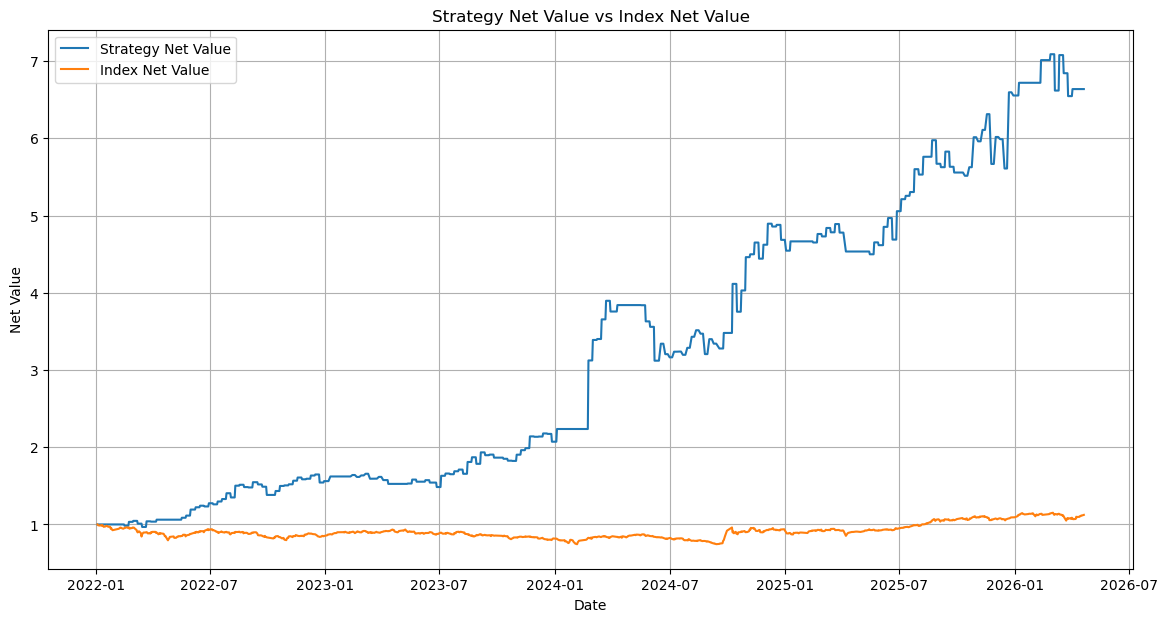

,指标名称,指标值
0,回测开始日期,2022-01-04
1,回测结束日期,2026-04-20
2,策略胜率,56.55%
3,策略盈亏比,1.47
4,每单位风险期望收益,0.3954
5,策略总收益率,563.70%
6,策略年化收益率,55.40%
7,最大回撤,-19.91%
8,最大回撤开始日期,2024-03-22
9,最大回撤结束日期,2024-06-07


In [ ]:
# ========== 理论回测报告（对照） ==========
from my_utils.trade_fun import report_backtest_full

merged_pdf = merged_df_theory.to_pandas() if isinstance(merged_df_theory, pl.DataFrame) else merged_df_theory
report_backtest_full(
    merged_pdf,
    start_date=START_DATE,
    end_date=END_DATE,
    profit_col='profit',
    buy_date_col='buy_time',
    sell_date_col='sell_time',
    holding_days_col='holding_days',
    benchmark_code='SHSE.000001',
)